In [20]:
# Olist E-Commerce — Customer Segmentation (RFM Analysis)
# Analyst: Nothabo Michelle Moyo
# Tool: Python · Jupyter Notebook
# Dataset: 96,475 customers - R$15,491,723 total revenue
# Method: RFM Scoring + Behavioural Segmentation

# ---
# Project Summary
# This notebook segments 96,475 Olist customers into 10 behavioural 
# groups using RFM analysis, Recency, Frequency, and Monetary value. 
# Each segment receives targeted business recommendations to guide 
# retention, re-engagement, and acquisition strategy.

In [21]:
# ================================================
# OLIST CUSTOMER SEGMENTATION — RFM ANALYSIS
# Analyst: Nothabo Michelle Moyo
# Tool: Python (Jupyter Notebook)
# Dataset: Olist Brazilian E-Commerce
# ================================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# ================================================
# STEP 1: LOAD AND EXPLORE THE DATA
# ================================================

# Load the dataset
df = pd.read_csv('final_cleaned_dataset.csv')

# Basic exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (104478, 22)

Column Names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_created', 'is_approved', 'is_shipped', 'is_delivered', 'approval_days', 'shipping_days', 'delivery_days', 'total_fulfillment_days', 'delivery_status', 'review_id', 'review_score', 'payment_type', 'payment_value', 'customer_state']

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_created,is_approved,...,approval_days,shipping_days,delivery_days,total_fulfillment_days,delivery_status,review_id,review_score,payment_type,payment_value,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,1,...,0.01,2.37,8.44,8.44,On Time,a54f0611adc9ed256b57ede6b6eb5114,4.00,credit_card,18.12,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,1,...,0.01,2.37,8.44,8.44,On Time,a54f0611adc9ed256b57ede6b6eb5114,4.00,voucher,2.00,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,1,...,0.01,2.37,8.44,8.44,On Time,a54f0611adc9ed256b57ede6b6eb5114,4.00,voucher,18.59,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,1,...,1.28,0.46,13.78,13.78,On Time,8d5266042046a06655c8db133d120ba5,4.00,boleto,141.46,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,1,...,0.01,0.20,9.39,9.39,On Time,e73b67b67587f7644d5bd1a52deb1b01,5.00,credit_card,179.12,GO


In [4]:
# Check the key columns for RFM
print("Key columns check:")
print("\norder_purchase_timestamp sample:")
print(df['order_purchase_timestamp'].head(3))
print("\nCustomer ID sample:")
print(df['customer_id'].head(3))
print("\nPayment value sample:")
print(df['payment_value'].head(3))
print("\nNull counts in key columns:")
print(df[['customer_id', 'order_purchase_timestamp', 'payment_value']].isnull().sum())

Key columns check:

order_purchase_timestamp sample:
0    2017-10-02 10:56:33
1    2017-10-02 10:56:33
2    2017-10-02 10:56:33
Name: order_purchase_timestamp, dtype: object

Customer ID sample:
0    9ef432eb6251297304e76186b10a928d
1    9ef432eb6251297304e76186b10a928d
2    9ef432eb6251297304e76186b10a928d
Name: customer_id, dtype: object

Payment value sample:
0   18.12
1    2.00
2   18.59
Name: payment_value, dtype: float64

Null counts in key columns:
customer_id                 0
order_purchase_timestamp    0
payment_value               1
dtype: int64


In [6]:
# ================================================
# STEP 2: PREPARE DATA FOR RFM ANALYSIS
# ================================================

# 1. Drop the 1 null payment value row
df = df.dropna(subset=['payment_value'])
print(f"Rows after dropping null payment: {len(df)}")

# 2. Keep only delivered orders
df_delivered = df[df['is_delivered'] == 1].copy()
print(f"Delivered orders only: {len(df_delivered)}")

# 3. Convert date column to datetime format
df_delivered['order_purchase_timestamp'] = pd.to_datetime(
    df_delivered['order_purchase_timestamp']
)

# 4. Reference date 
reference_date = df_delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"\nReference date for recency calculation: {reference_date.date()}")

# 5. Preview
print("\nData ready for RFM calculation")
print(f"Date range: {df_delivered['order_purchase_timestamp'].min().date()} "
      f"to {df_delivered['order_purchase_timestamp'].max().date()}")

Rows after dropping null payment: 104477
Delivered orders only: 101323

Reference date for recency calculation: 2018-08-30

Data ready for RFM calculation
Date range: 2016-10-03 to 2018-08-29


In [7]:
# ================================================
# STEP 3: CALCULATE RFM SCORES
# ================================================

# RFM metrics per customer
rfm = df_delivered.groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', 
             lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("RFM Table — First 5 rows:")
print(rfm.head())

print(f"\nTotal unique customers: {len(rfm)}")
print(f"\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

RFM Table — First 5 rows:
                        customer_id  Recency  Frequency  Monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74
1  000161a058600d5901f007fab4c27140      410          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35
4  000379cdec625522490c315e70c7a9fb      150          1    107.01

Total unique customers: 96475

RFM Summary Statistics:
       Recency  Frequency  Monetary
count 96475.00   96475.00  96475.00
mean    240.15       1.05    160.58
std     152.86       0.39    219.65
min       1.00       1.00      9.59
25%     116.00       1.00     62.08
50%     221.00       1.00    105.48
75%     350.00       1.00    177.13
max     696.00      26.00  13664.08


In [8]:
# Scoring each customer 1-4 on each RFM dimension
# Recency: lower days = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, 
                          labels=[4, 3, 2, 1])

# Frequency: higher count = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, 
                          labels=[1, 2, 3, 4])

# Monetary: higher spend = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, 
                          labels=[1, 2, 3, 4])

# Combining into one RFM score
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

print("RFM Scores added:")
print(rfm[['customer_id', 'Recency', 'Frequency', 
           'Monetary', 'R_Score', 'F_Score', 
           'M_Score', 'RFM_Score']].head(10))

RFM Scores added:
                        customer_id  Recency  Frequency  Monetary R_Score  \
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74       2   
1  000161a058600d5901f007fab4c27140      410          1     67.41       1   
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42       1   
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35       1   
4  000379cdec625522490c315e70c7a9fb      150          1    107.01       3   
5  0004164d20a9e969af783496f3408652      505          1     71.80       1   
6  000419c5494106c306a97b5635748086      180          1     49.40       3   
7  00046a560d407e99b969756e0b10f282      255          1    166.59       2   
8  00050bf6e01e69d5c0fd612f1bcfb69c      346          1     85.23       2   
9  000598caf2ef4117407665ac33275130       19          1   1255.71       4   

  F_Score M_Score RFM_Score  
0       1       3       213  
1       1       2       112  
2       1       4       114  
3       1     

In [9]:
# ================================================
# STEP 4: ASSIGN CUSTOMER SEGMENTS
# ================================================

def assign_segment(r, f, m):
    r, f, m = int(r), int(f), int(m)
    
    if r == 4 and f >= 3:
        return 'Champions'
    elif r == 4 and f < 3 and m >= 3:
        return 'High Value New'
    elif r == 4 and f < 3 and m < 3:
        return 'Promising New'
    elif r == 3 and f >= 2:
        return 'Loyal Customers'
    elif r == 3 and f < 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 2 and f >= 2:
        return 'Needs Attention'
    elif r == 2 and f < 2 and m >= 3:
        return 'At Risk — High Value'
    elif r == 2 and f < 2 and m < 3:
        return 'At Risk — Low Value'
    elif r == 1 and m >= 3:
        return 'Lost — High Value'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(
    lambda x: assign_segment(x['R_Score'], x['F_Score'], x['M_Score']), 
    axis=1
)

# Segment summary
segment_summary = rfm.groupby('Segment').agg(
    Customers=('customer_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2).reset_index()

segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)

print("Customer Segments:")
print(segment_summary.to_string(index=False))
print(f"\nTotal customers segmented: {rfm['Segment'].count()}")

Customer Segments:
             Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
   Lost — High Value      11625       455.10           1.07        264.62     3076196.89
     Needs Attention      18112       280.28           1.07        160.78     2911987.93
     Loyal Customers      18134       168.76           1.06        159.12     2885411.13
           Champions      11866        58.35           1.07        165.60     1965043.21
      High Value New       6262        60.25           1.00        259.72     1626356.18
                Lost      15424       396.96           1.05         62.48      963668.15
At Risk — High Value       2990       280.59           1.00        249.87      747115.27
 Potential Loyalists       2940       168.22           1.00        253.78      746127.78
       Promising New       6036        58.02           1.00         62.16      375191.76
 At Risk — Low Value       3086       280.25           1.00         63.07      194624.95

T

In [10]:
# Percentage share of each segment
segment_summary['Customer_%'] = (
    segment_summary['Customers'] / segment_summary['Customers'].sum() * 100
).round(2)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100
).round(2)

print("Segment Share Summary:")
print(segment_summary[['Segment', 'Customers', 'Customer_%', 
                        'Total_Revenue', 'Revenue_%']].to_string(index=False))

Segment Share Summary:
             Segment  Customers  Customer_%  Total_Revenue  Revenue_%
   Lost — High Value      11625       12.05     3076196.89      19.86
     Needs Attention      18112       18.77     2911987.93      18.80
     Loyal Customers      18134       18.80     2885411.13      18.63
           Champions      11866       12.30     1965043.21      12.68
      High Value New       6262        6.49     1626356.18      10.50
                Lost      15424       15.99      963668.15       6.22
At Risk — High Value       2990        3.10      747115.27       4.82
 Potential Loyalists       2940        3.05      746127.78       4.82
       Promising New       6036        6.26      375191.76       2.42
 At Risk — Low Value       3086        3.20      194624.95       1.26


In [11]:
# ================================================
# STEP 5: VISUALISATIONS
# ================================================

# Colour palette — one colour per segment
segment_colors = {
    'Champions':            '#2ecc71',
    'High Value New':       '#27ae60',
    'Loyal Customers':      '#3498db',
    'Promising New':        '#1abc9c',
    'Potential Loyalists':  '#9b59b6',
    'Needs Attention':      '#f39c12',
    'At Risk — High Value': '#e67e22',
    'At Risk — Low Value':  '#e74c3c',
    'Lost — High Value':    '#c0392b',
    'Lost':                 '#7f8c8d'
}

print("Colour palette ready")

Colour palette ready


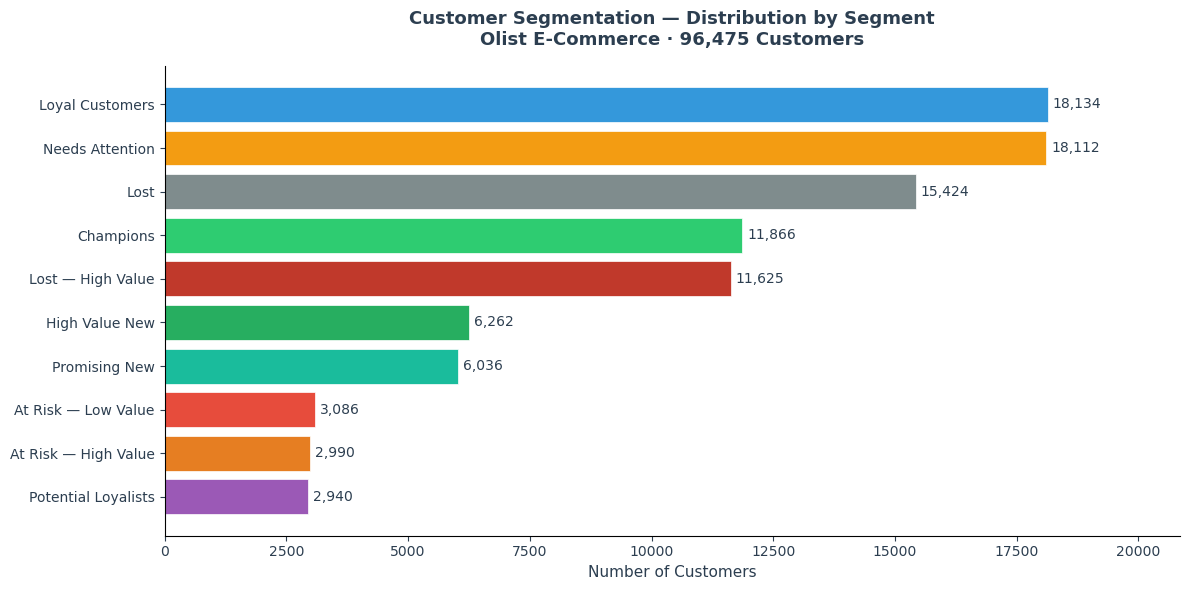

Chart 1 saved


In [12]:
# ---- CHART 1: Customer Count by Segment ----
fig, ax = plt.subplots(figsize=(12, 6))

seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Customers']
seg_counts = seg_counts.sort_values('Customers', ascending=True)

colors = [segment_colors[s] for s in seg_counts['Segment']]

bars = ax.barh(seg_counts['Segment'], seg_counts['Customers'], 
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, seg_counts['Customers']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, color='#2c3e50')

ax.set_xlabel('Number of Customers', fontsize=11, color='#2c3e50')
ax.set_title('Customer Segmentation — Distribution by Segment\nOlist E-Commerce · 96,475 Customers',
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlim(0, seg_counts['Customers'].max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')

plt.tight_layout()
plt.savefig('chart1_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

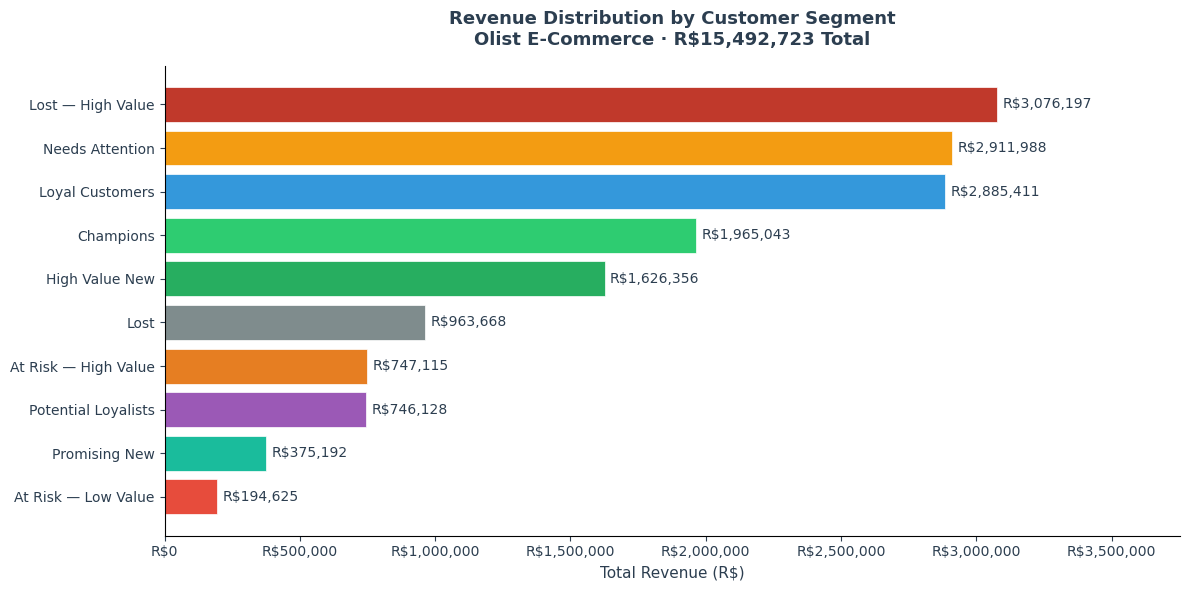

Chart 2 saved


In [13]:
# ---- CHART 2: Revenue by Segment ----
fig, ax = plt.subplots(figsize=(12, 6))

rev_data = segment_summary.sort_values('Total_Revenue', ascending=True)
colors = [segment_colors[s] for s in rev_data['Segment']]

bars = ax.barh(rev_data['Segment'], rev_data['Total_Revenue'],
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, rev_data['Total_Revenue']):
    ax.text(bar.get_width() + 20000, bar.get_y() + bar.get_height()/2,
            f'R${val:,.0f}', va='center', fontsize=10, color='#2c3e50')

ax.set_xlabel('Total Revenue (R$)', fontsize=11, color='#2c3e50')
ax.set_title('Revenue Distribution by Customer Segment\nOlist E-Commerce · R$15,492,723 Total',
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlim(0, rev_data['Total_Revenue'].max() * 1.22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')

# Format x axis as currency
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

plt.tight_layout()
plt.savefig('chart2_revenue_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

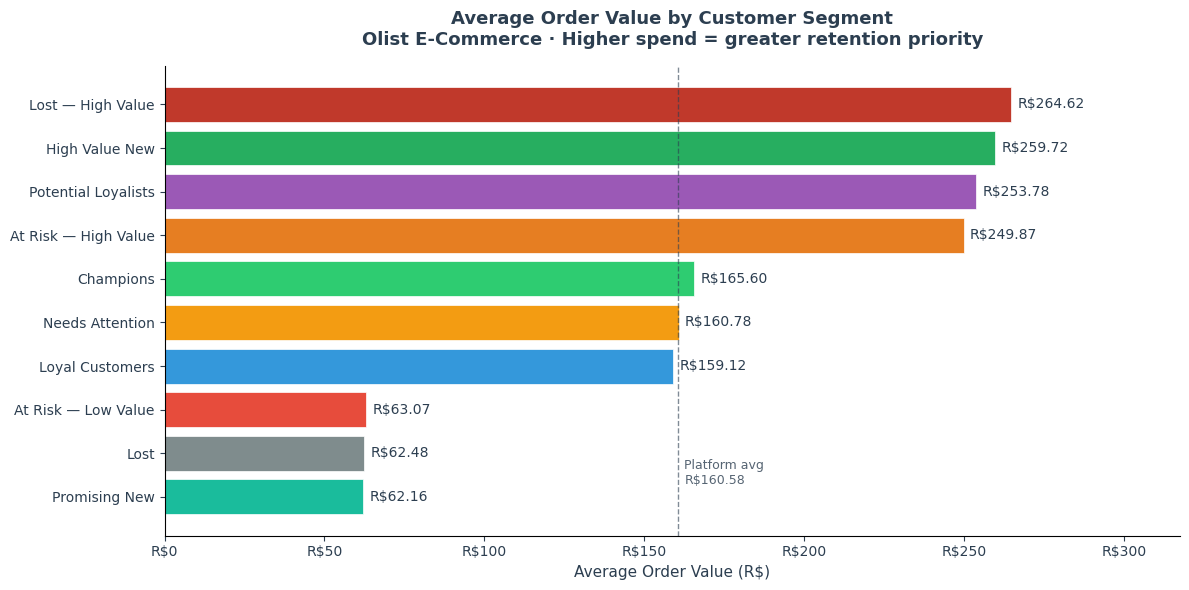

Chart 3 saved


In [14]:
# ---- CHART 3: Average Order Value by Segment ----
fig, ax = plt.subplots(figsize=(12, 6))

aov_data = segment_summary.sort_values('Avg_Monetary', ascending=True)
colors = [segment_colors[s] for s in aov_data['Segment']]

bars = ax.barh(aov_data['Segment'], aov_data['Avg_Monetary'],
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, aov_data['Avg_Monetary']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'R${val:,.2f}', va='center', fontsize=10, color='#2c3e50')

ax.set_xlabel('Average Order Value (R$)', fontsize=11, color='#2c3e50')
ax.set_title('Average Order Value by Customer Segment\nOlist E-Commerce · Higher spend = greater retention priority',
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlim(0, aov_data['Avg_Monetary'].max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

# Reference line at the overall average
overall_avg = rfm['Monetary'].mean()
ax.axvline(x=overall_avg, color='#2c3e50', linestyle='--', 
           linewidth=1, alpha=0.6)
ax.text(overall_avg + 2, 0.3, f'Platform avg\nR${overall_avg:.2f}',
        fontsize=9, color='#2c3e50', alpha=0.8)

plt.tight_layout()
plt.savefig('chart3_avg_order_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

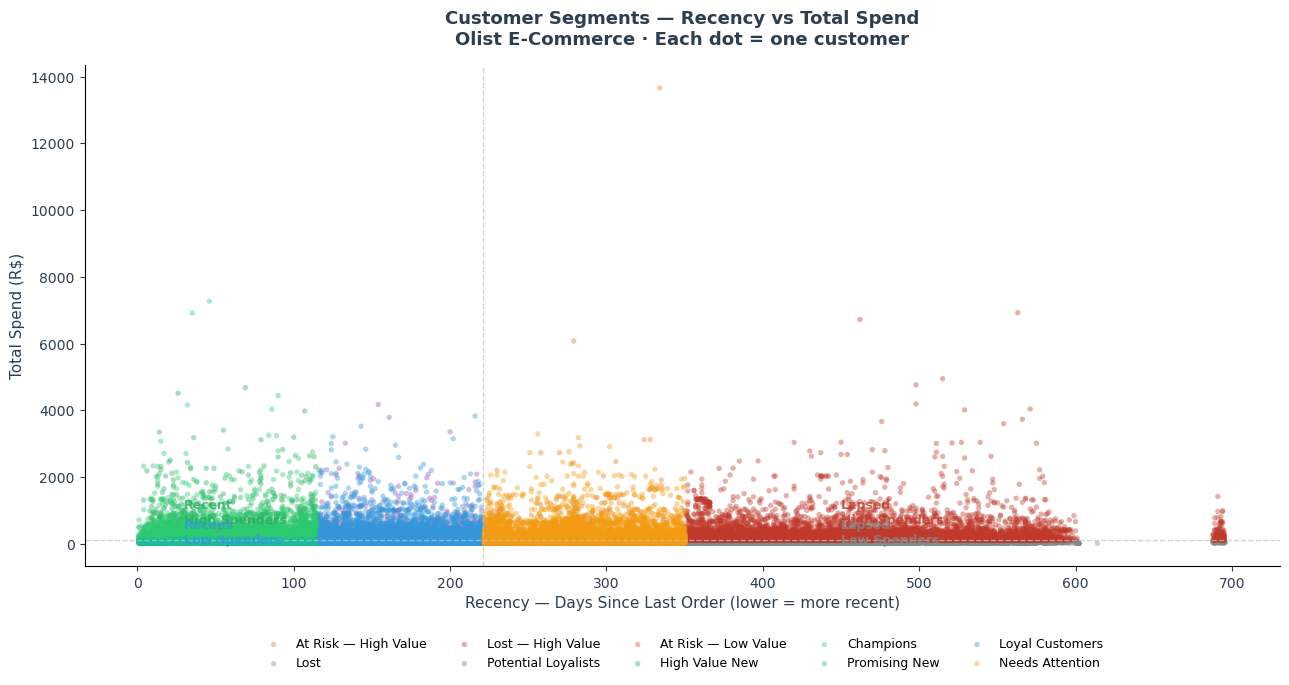

Chart 4 saved


In [15]:
# ---- CHART 4: RFM Scatter Plot — Recency vs Monetary ----
fig, ax = plt.subplots(figsize=(13, 7))

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    ax.scatter(
        subset['Recency'],
        subset['Monetary'],
        c=segment_colors[segment],
        label=segment,
        alpha=0.4,
        s=15,
        edgecolors='none'
    )

ax.set_xlabel('Recency — Days Since Last Order (lower = more recent)', 
              fontsize=11, color='#2c3e50')
ax.set_ylabel('Total Spend (R$)', fontsize=11, color='#2c3e50')
ax.set_title('Customer Segments — Recency vs Total Spend\nOlist E-Commerce · Each dot = one customer',
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)

# Add quadrant lines at medians
ax.axvline(x=rfm['Recency'].median(), color='#bdc3c7', 
           linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=rfm['Monetary'].median(), color='#bdc3c7', 
           linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels
ax.text(30, rfm['Monetary'].quantile(0.97), 
        'Recent\nHigh Spenders', fontsize=9, color='#27ae60',
        fontweight='bold', alpha=0.8)
ax.text(450, rfm['Monetary'].quantile(0.97), 
        'Lapsed\nHigh Spenders', fontsize=9, color='#c0392b',
        fontweight='bold', alpha=0.8)
ax.text(30, rfm['Monetary'].quantile(0.01), 
        'Recent\nLow Spenders', fontsize=9, color='#3498db',
        fontweight='bold', alpha=0.8)
ax.text(450, rfm['Monetary'].quantile(0.01), 
        'Lapsed\nLow Spenders', fontsize=9, color='#7f8c8d',
        fontweight='bold', alpha=0.8)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=5, fontsize=9, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')

plt.tight_layout()
plt.savefig('chart4_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

In [16]:
# ================================================
# STEP 6: BUSINESS SUMMARY OUTPUT
# ================================================

total_customers = len(rfm)
total_revenue = rfm['Monetary'].sum()

print("=" * 60)
print("OLIST CUSTOMER SEGMENTATION — EXECUTIVE SUMMARY")
print("=" * 60)

print(f"\nTotal Customers Analysed:  {total_customers:,}")
print(f"Total Revenue:             R${total_revenue:,.2f}")

print("\n--- SEGMENT BREAKDOWN ---")
for _, row in segment_summary.sort_values(
        'Total_Revenue', ascending=False).iterrows():
    print(f"{row['Segment']:<25} "
          f"Customers: {row['Customers']:>6,} ({row['Customer_%']:>5.1f}%)  "
          f"Revenue: R${row['Total_Revenue']:>12,.2f} ({row['Revenue_%']:>5.1f}%)")

print("\n--- KEY FINDINGS ---")
print("""
1. Lost — High Value is the single largest revenue segment at R$3,076,197
   (19.86%), these customers spent the most and have not returned.
   Average order value: R$264.62, the highest of any segment.

2. 32% of customers (Needs Attention + At Risk) are at risk of churning.
   Combined revenue exposure: R$3,853,728.

3. Champions represent only 12.3% of customers but are the platform's
   most engaged segment, recent, frequent, and high spending.

4. 94% of customers have a frequency of 1, a structural characteristic
   of Brazilian e-commerce. Repeat purchase is the platform's
   single biggest growth opportunity.

5. Promising New and Lost — Low Value segments spend R$62 on average,
   less than half the platform average of R$160.58.
   Low-value acquisition is not the growth lever.
""")

print("=" * 60)
print("Charts saved: chart1-4_*.png")
print("=" * 60)

OLIST CUSTOMER SEGMENTATION — EXECUTIVE SUMMARY

Total Customers Analysed:  96,475
Total Revenue:             R$15,491,723.25

--- SEGMENT BREAKDOWN ---
Lost — High Value         Customers: 11,625 ( 12.1%)  Revenue: R$3,076,196.89 ( 19.9%)
Needs Attention           Customers: 18,112 ( 18.8%)  Revenue: R$2,911,987.93 ( 18.8%)
Loyal Customers           Customers: 18,134 ( 18.8%)  Revenue: R$2,885,411.13 ( 18.6%)
Champions                 Customers: 11,866 ( 12.3%)  Revenue: R$1,965,043.21 ( 12.7%)
High Value New            Customers:  6,262 (  6.5%)  Revenue: R$1,626,356.18 ( 10.5%)
Lost                      Customers: 15,424 ( 16.0%)  Revenue: R$  963,668.15 (  6.2%)
At Risk — High Value      Customers:  2,990 (  3.1%)  Revenue: R$  747,115.27 (  4.8%)
Potential Loyalists       Customers:  2,940 (  3.0%)  Revenue: R$  746,127.78 (  4.8%)
Promising New             Customers:  6,036 (  6.3%)  Revenue: R$  375,191.76 (  2.4%)
At Risk — Low Value       Customers:  3,086 (  3.2%)  Revenue: R